# UCI Parkinson's Disease Detection using Machine Learning

## Objective
Build a clean machine learning pipeline to detect Parkinson's disease using the **UCI Parkinson's voice dataset**.

## Dataset
File used: `parkinsons.data`

## Target
- `status = 1`: Parkinson's disease
- `status = 0`: Healthy control

## Models Used
We will use only two models:
1. Logistic Regression
2. Gradient Boosting Classifier

## Main Steps
1. Load dataset
2. Exploratory Data Analysis
3. Preprocessing
4. Train/test split
5. Train two models
6. Evaluate models
7. Add adversarial condition using label noise
8. Compare clean vs noisy-label performance
9. Write interpretation and limitations

In [1]:
# =========================
# 1. Import libraries
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

We load the UCI Parkinson's dataset from the file `parkinsons.data`.

In [2]:
# =========================
# 2. Load dataset
# =========================

df = pd.read_csv("parkinsons.data")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 3. Initial Data Inspection

We inspect:
- Number of rows and columns
- Data types
- Basic statistics
- Missing values

In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [4]:
# Summary statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [5]:
# Check missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found.")

,0


No missing values found.


## 4. Exploratory Data Analysis

The target column is `status`.

We check class distribution to understand whether the dataset is balanced or imbalanced.

,count
status,
0,48
1,147


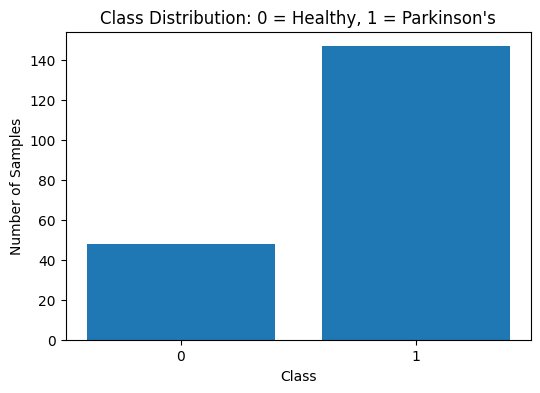

In [6]:
# Class distribution
class_counts = df["status"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution: 0 = Healthy, 1 = Parkinson's")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

## 5. Correlation Analysis

We check which features are most correlated with the target variable.
This gives a simple idea about which features may be useful for prediction.

,status
spread1,0.564838
PPE,0.531039
spread2,0.454842
MDVP:Fo(Hz),-0.383535
MDVP:Flo(Hz),-0.380200
MDVP:Shimmer,0.367430
MDVP:APQ,0.364316
HNR,-0.361515
Shimmer:APQ5,0.351148
MDVP:Shimmer(dB),0.350697


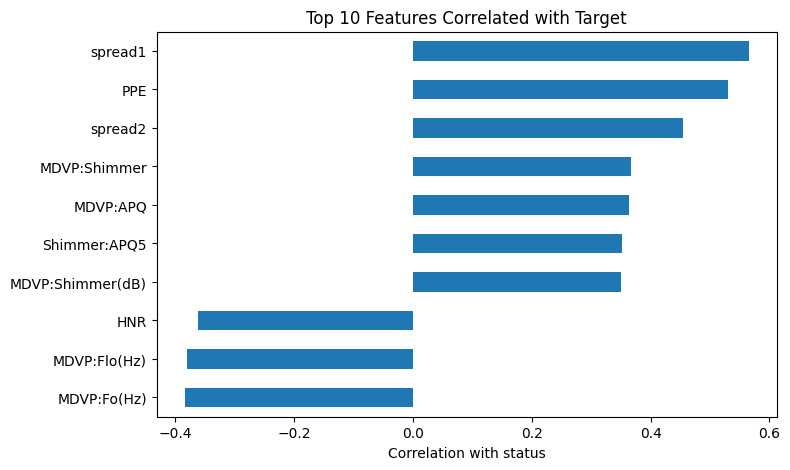

In [7]:
# Remove the non-numeric identifier column before correlation
numeric_df = df.drop(columns=["name"])

correlations = numeric_df.corr(numeric_only=True)["status"].drop("status")
top_correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

display(top_correlations.head(10))

plt.figure(figsize=(8, 5))
top_correlations.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features Correlated with Target")
plt.xlabel("Correlation with status")
plt.show()

## 6. Prepare Features and Target

We remove:
- `name`: identifier column
- `status`: target column

The remaining columns are used as input features.

In [8]:
# =========================
# 6. Feature-target split
# =========================

X = df.drop(columns=["name", "status"])
y = df["status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (195, 22)
Target shape: (195,)


## 7. Train/Test Split

We use a stratified split to preserve the same class distribution in both train and test sets.

In [9]:
# =========================
# 7. Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True))

X_train: (156, 22)
X_test: (39, 22)

Train class distribution:


,proportion
status,
1,0.75641
0,0.24359



Test class distribution:


,proportion
status,
1,0.74359
0,0.25641


## 8. Define the Two Models

### Logistic Regression
A simple and interpretable baseline model.  
It needs feature scaling, so we use `StandardScaler`.

### Gradient Boosting
A stronger tree-based model that can capture non-linear relationships.

In [10]:
# =========================
# 8. Define models
# =========================

from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ])
}

## 9. Model Evaluation Function

This function:
1. Trains the model
2. Predicts on the test set
3. Calculates:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
4. Prints classification report and confusion matrix
5. Plots ROC curve

In [11]:
# =========================
# 9. Evaluation function
# =========================

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train and evaluate a classification model."""

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    return results

## 10. Train and Evaluate on Clean Data

First, we train the models on the original clean training data.

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39

Confusion Matrix:
[[ 9  1]
 [ 8 21]]


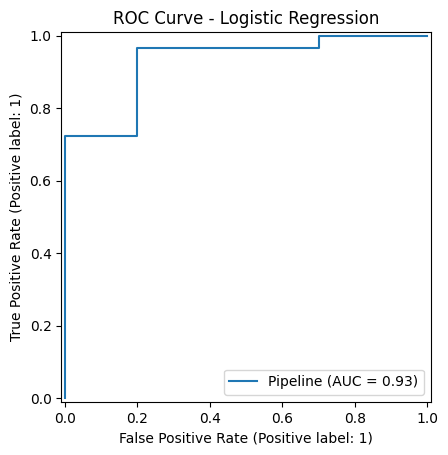

Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.90      0.90      0.90        29

    accuracy                           0.85        39
   macro avg       0.80      0.80      0.80        39
weighted avg       0.85      0.85      0.85        39

Confusion Matrix:
[[ 7  3]
 [ 3 26]]


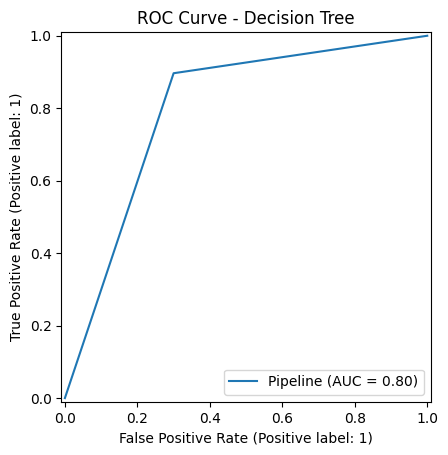

Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39

Confusion Matrix:
[[ 9  1]
 [ 2 27]]


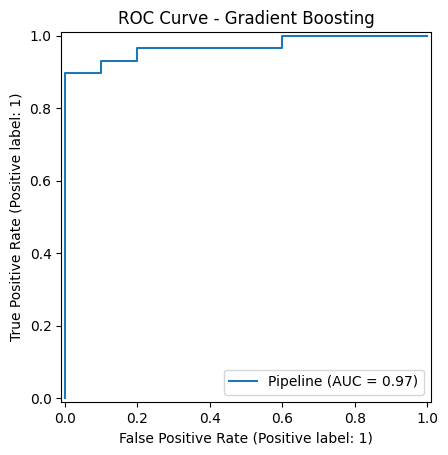

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.769231,0.954545,0.724138,0.823529,0.927586
1,Decision Tree,0.846154,0.896552,0.896552,0.896552,0.798276
2,Gradient Boosting,0.923077,0.964286,0.931034,0.947368,0.968966


In [12]:
# =========================
# 10. Train and evaluate clean models
# =========================

clean_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name
    )
    clean_results.append(result)

clean_results_df = pd.DataFrame(clean_results)
display(clean_results_df)

## 11. Cross-Validation

Cross-validation gives a more reliable estimate than a single train/test split.

In [13]:
# =========================
# 11. Cross-validation
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.814113,0.031452,0.943247,0.034634,0.805072,0.043968,0.867347,0.022745,0.900401,0.044218
1,Decision Tree,0.820363,0.017112,0.886578,0.041531,0.881522,0.074055,0.880326,0.017092,0.756832,0.048169
2,Gradient Boosting,0.871976,0.027776,0.898896,0.042496,0.940580,0.051475,0.917232,0.018763,0.949198,0.027183


## 12. Hyperparameter Tuning for Gradient Boosting

We tune Gradient Boosting because it is usually stronger for tabular data.

In [14]:
# =========================
# 12. Hyperparameter tuning
# =========================

gb_pipeline = Pipeline(steps=[
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

best_gb_model = grid_search.best_estimator_

Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 150}
Best CV F1-score: 0.9427106227106228


Tuned Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39

Confusion Matrix:
[[ 8  2]
 [ 2 27]]


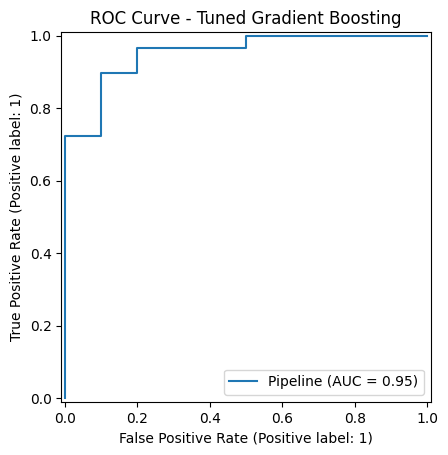

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Gradient Boosting,0.923077,0.964286,0.931034,0.947368,0.968966
3,Tuned Gradient Boosting,0.897436,0.931034,0.931034,0.931034,0.951724
1,Decision Tree,0.846154,0.896552,0.896552,0.896552,0.798276
0,Logistic Regression,0.769231,0.954545,0.724138,0.823529,0.927586


In [15]:
# Evaluate tuned Gradient Boosting
tuned_gb_result = evaluate_model(
    best_gb_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Tuned Gradient Boosting"
)

clean_results_df = pd.concat(
    [clean_results_df, pd.DataFrame([tuned_gb_result])],
    ignore_index=True
)

display(clean_results_df.sort_values(by="F1-score", ascending=False))

## 13. Adversarial Condition: Label Noise

To simulate real-world data errors, we flip a percentage of training labels.

This represents situations such as:
- Misdiagnosis
- Incorrect patient labeling
- Data entry mistakes

Important:
The test labels remain clean.  
Only the training labels are modified.

In [16]:
# =========================
# 13. Add label noise
# =========================

def add_label_noise(y, noise_level=0.15, random_state=42):
    """
    Flip a percentage of binary labels.

    Parameters:
    y: target labels
    noise_level: percentage of labels to flip
    random_state: reproducibility seed

    Returns:
    y_noisy: noisy labels
    noisy_indices: indices where labels were flipped
    """

    rng = np.random.default_rng(random_state)
    y_noisy = y.copy().reset_index(drop=True)

    n_noisy = int(len(y_noisy) * noise_level)
    noisy_indices = rng.choice(len(y_noisy), size=n_noisy, replace=False)

    y_noisy.iloc[noisy_indices] = 1 - y_noisy.iloc[noisy_indices]

    return y_noisy, noisy_indices


noise_level = 0.15

X_train_noisy = X_train.reset_index(drop=True)
y_train_noisy, noisy_indices = add_label_noise(
    y_train,
    noise_level=noise_level,
    random_state=RANDOM_STATE
)

print(f"Noise level: {noise_level * 100:.0f}%")
print("Number of flipped labels:", len(noisy_indices))

print("\nOriginal training label distribution:")
display(y_train.reset_index(drop=True).value_counts())

print("\nNoisy training label distribution:")
display(y_train_noisy.value_counts())

Noise level: 15%
Number of flipped labels: 23

Original training label distribution:


,count
status,
1,118
0,38



Noisy training label distribution:


,count
status,
1,103
0,53


## 14. Train and Evaluate Under Label Noise

Now we train the same models using noisy training labels.
Then we evaluate them on the original clean test set.

Logistic Regression - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.45      1.00      0.62        10
           1       1.00      0.59      0.74        29

    accuracy                           0.69        39
   macro avg       0.73      0.79      0.68        39
weighted avg       0.86      0.69      0.71        39

Confusion Matrix:
[[10  0]
 [12 17]]


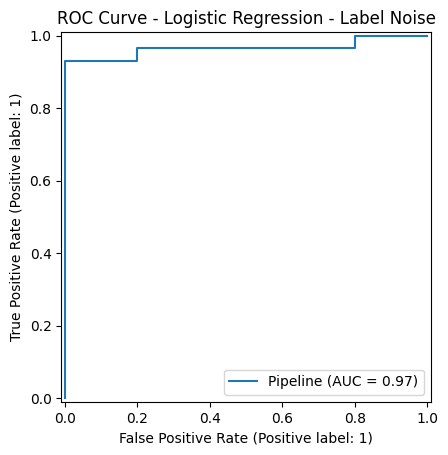

Decision Tree - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        10
           1       0.88      0.79      0.84        29

    accuracy                           0.77        39
   macro avg       0.71      0.75      0.72        39
weighted avg       0.80      0.77      0.78        39

Confusion Matrix:
[[ 7  3]
 [ 6 23]]


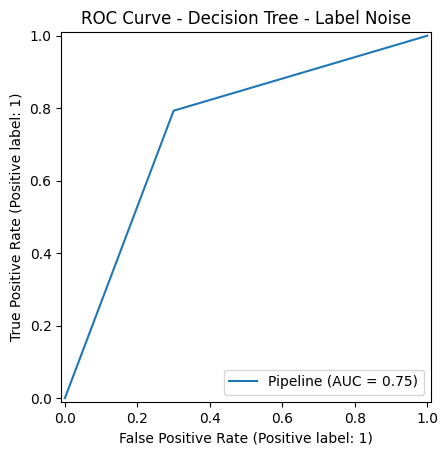

Gradient Boosting - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        10
           1       0.96      0.86      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.88      0.85        39
weighted avg       0.89      0.87      0.88        39

Confusion Matrix:
[[ 9  1]
 [ 4 25]]


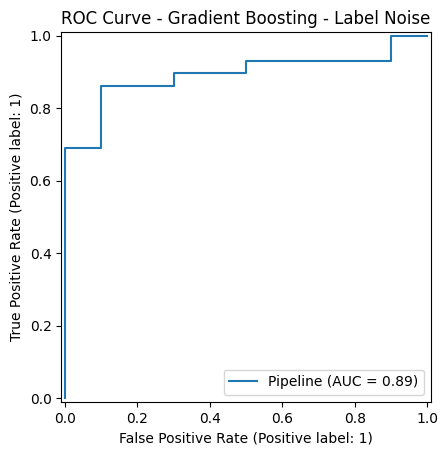

Tuned Gradient Boosting - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.89      0.83      0.86        29

    accuracy                           0.79        39
   macro avg       0.74      0.76      0.75        39
weighted avg       0.81      0.79      0.80        39

Confusion Matrix:
[[ 7  3]
 [ 5 24]]


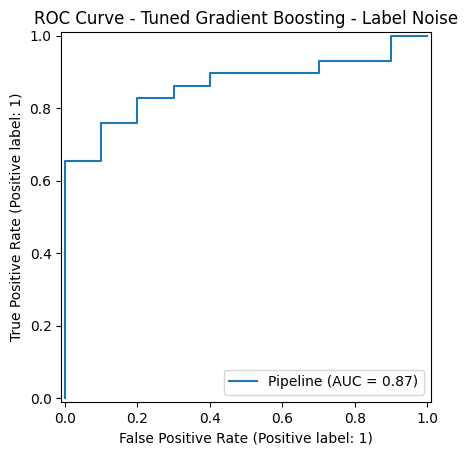

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Gradient Boosting - Label Noise,0.871795,0.961538,0.862069,0.909091,0.893103
3,Tuned Gradient Boosting - Label Noise,0.794872,0.888889,0.827586,0.857143,0.865517
1,Decision Tree - Label Noise,0.769231,0.884615,0.793103,0.836364,0.746552
0,Logistic Regression - Label Noise,0.692308,1.000000,0.586207,0.739130,0.965517


In [17]:
# =========================
# 14. Evaluate noisy-label training
# =========================

noisy_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train_noisy,
        y_train_noisy,
        X_test,
        y_test,
        model_name + " - Label Noise"
    )
    noisy_results.append(result)

# Tuned Gradient Boosting under label noise
tuned_noise_result = evaluate_model(
    best_gb_model,
    X_train_noisy,
    y_train_noisy,
    X_test,
    y_test,
    "Tuned Gradient Boosting - Label Noise"
)

noisy_results.append(tuned_noise_result)

noisy_results_df = pd.DataFrame(noisy_results)
display(noisy_results_df.sort_values(by="F1-score", ascending=False))

## 15. Final Comparison

We compare clean training performance against noisy-label training performance.

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Condition
1,Decision Tree,0.846154,0.896552,0.896552,0.896552,0.798276,Clean Training
5,Decision Tree - Label Noise,0.769231,0.884615,0.793103,0.836364,0.746552,Label Noise Training
2,Gradient Boosting,0.923077,0.964286,0.931034,0.947368,0.968966,Clean Training
6,Gradient Boosting - Label Noise,0.871795,0.961538,0.862069,0.909091,0.893103,Label Noise Training
0,Logistic Regression,0.769231,0.954545,0.724138,0.823529,0.927586,Clean Training
4,Logistic Regression - Label Noise,0.692308,1.000000,0.586207,0.739130,0.965517,Label Noise Training
3,Tuned Gradient Boosting,0.897436,0.931034,0.931034,0.931034,0.951724,Clean Training
7,Tuned Gradient Boosting - Label Noise,0.794872,0.888889,0.827586,0.857143,0.865517,Label Noise Training


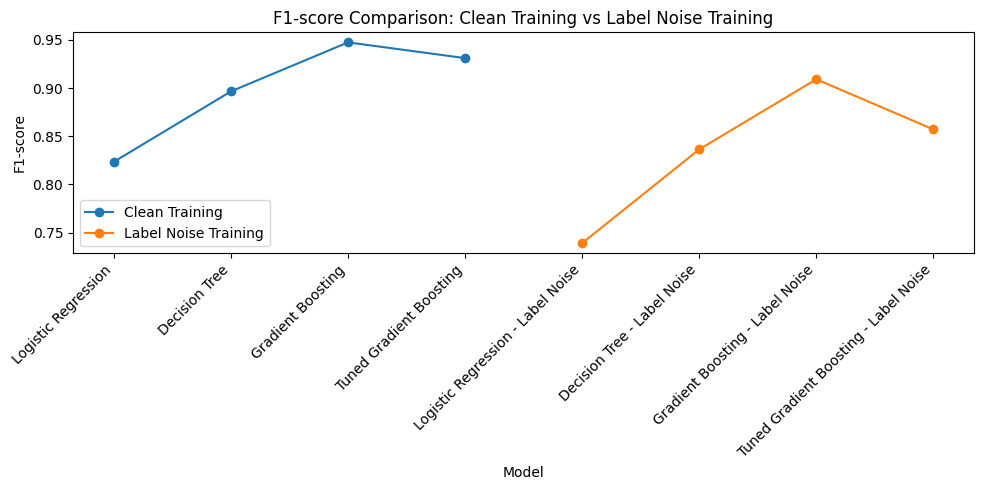

In [18]:
# =========================
# 15. Compare clean vs noisy results
# =========================

clean_comparison = clean_results_df.copy()
clean_comparison["Condition"] = "Clean Training"

noisy_comparison = noisy_results_df.copy()
noisy_comparison["Condition"] = "Label Noise Training"

comparison_df = pd.concat(
    [clean_comparison, noisy_comparison],
    ignore_index=True
)

display(comparison_df.sort_values(by=["Model", "Condition"]))

plt.figure(figsize=(10, 5))

for condition in comparison_df["Condition"].unique():
    subset = comparison_df[comparison_df["Condition"] == condition]
    plt.plot(
        subset["Model"],
        subset["F1-score"],
        marker="o",
        label=condition
    )

plt.title("F1-score Comparison: Clean Training vs Label Noise Training")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Interpretation

Use this section after running the notebook and seeing the numbers.

### Clean Data Performance
The models were first trained on the original clean UCI dataset.  
Logistic Regression acts as a simple baseline, while Gradient Boosting is expected to perform better because it can capture non-linear relationships between voice features and Parkinson's status.

### Adversarial Condition
After adding label noise, some training labels were intentionally flipped.  
This simulates real-world labeling errors such as misdiagnosis or incorrect medical records.

If performance drops under label noise, this means the model is sensitive to incorrect training labels.

### Why Performance May Drop
The model learns patterns from the training data.  
When some labels are wrong, the model receives misleading examples, which can reduce its ability to generalize correctly to unseen clean test data.

## 17. Honest Limitation Analysis

1. **Small dataset size**  
   The UCI dataset has only 195 samples, so the results may not generalize well to larger real-world clinical populations.

2. **Voice-only features**  
   The dataset is based on voice measurements only. Parkinson's disease is complex and may require clinical, motor, imaging, and demographic features for more reliable diagnosis.

3. **Possible overfitting**  
   Because the dataset is small, complex models such as Gradient Boosting may overfit.

4. **Label noise sensitivity**  
   When incorrect labels are introduced, model performance may decrease because the model learns from wrong examples.

5. **Not clinically deployable alone**  
   The model can support early screening, but it cannot replace medical diagnosis by clinicians.

6. **Need for external validation**  
   The model should be tested on larger clinical datasets such as PPMI before making stronger conclusions.

## 18. Final Conclusion

This notebook built a complete machine learning pipeline for Parkinson's disease detection using the UCI Parkinson's dataset.

Two models were trained:
- Logistic Regression
- Gradient Boosting

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

An adversarial label-noise experiment was also performed to test robustness.  
The final results help us understand not only which model performs best, but also how reliable it is under imperfect real-world data conditions.